# Method 4 — Theil–Sen and Kendall trend robustness

This notebook subjects the direction of change on the four main outcomes to stress testing. Theil-Sen generates a robust annual slope by finding the median of all slopes between pairs of data points, such that one anomalous year has lesser impact compared to what it would have on a linear least-squares regression line. Kendall’s tau answers another, albeit similar, question: are later data points ranked higher or lower than earlier data points?

The analysis is **still purely descriptive**. The common trend in material and social outcomes does not imply causation in either direction.

## Analysis rules fixed before estimation

- Household income and employment are measured by using the annual data from **2010-2024**.
- The lack of social support and negative affect are calculated using the Gallup three-year pooled estimate. Because repeated annual rows are not independent, each window is represented just once at its midpoint: **2009, 2012, 2015, 2018, 2021, and 2024**.
- The slopes are provided in the units of the indicator per year. In addition to that, the slopes are reoriented to ensure that positive numbers reflect improvements in the indicators: the same sign is kept for income and employment, while the sign is reversed for lack of support and negative affect.
- Kendall’s tau is calculated on the natural scale of the indicator. The p-value does not change when the outcome is sign-reversed, but there is a favourable-scale Kendall’s tau for interpretative purposes.
- Kendall’s tau describes the direction and strength of monotonic ordering. Raw p-values test the null of no ordinal association, and Holm adjustment controls family-wise multiplicity across the four pre-specified Australian tests.
- Because observations form time series, temporal dependence may make standard Kendall p-values and Theil–Sen intervals overconfident. They are reported as exploratory diagnostics, not decisive significance tests.
- Countries enter a slope distribution only when they share Australia’s start and endpoint and provide at least 80% of Australia’s independent periods for that outcome.

With only six independent social observations, the emphasis is on direction, effect size and agreement with the endpoint analysis—not on crossing a significance threshold.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kendalltau, theilslopes
from IPython.display import display

PROJECT_ROOT = Path.cwd() / "submission" if (Path.cwd() / "submission" / "OECD Data.csv").exists() else (Path.cwd().parent if Path.cwd().name == "code" else Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "oecd_clean.csv"
PRIMARY_RESULTS_PATH = PROJECT_ROOT / "report" / "tables" / "material_social_primary_results.csv"
TABLE_DIR = PROJECT_ROOT / "report" / "tables"
FIGURE_DIR = PROJECT_ROOT / "report" / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

INDICATORS = {
    "1_1": {
        "short_name": "Household income",
        "better": "higher",
        "native_unit_per_year": "PPP USD per person per year",
        "analysis_type": "annual",
    },
    "2_1": {
        "short_name": "Employment rate",
        "better": "higher",
        "native_unit_per_year": "percentage points per year",
        "analysis_type": "annual",
    },
    "7_1_DEP": {
        "short_name": "Lack of social support",
        "better": "lower",
        "native_unit_per_year": "percentage points per year",
        "analysis_type": "pooled",
    },
    "11_2": {
        "short_name": "Negative affect",
        "better": "lower",
        "native_unit_per_year": "percentage points per year",
        "analysis_type": "pooled",
    },
}

WINDOWS = {
    2010: ("2008–10", 2009),
    2011: ("2011–13", 2012), 2012: ("2011–13", 2012), 2013: ("2011–13", 2012),
    2014: ("2014–16", 2015), 2015: ("2014–16", 2015), 2016: ("2014–16", 2015),
    2017: ("2017–19", 2018), 2018: ("2017–19", 2018), 2019: ("2017–19", 2018),
    2020: ("2020–22", 2021), 2021: ("2020–22", 2021), 2022: ("2020–22", 2021),
    2023: ("2023–25", 2024), 2024: ("2023–25", 2024), 2025: ("2023–25", 2024),
}

df = pd.read_csv(DATA_PATH)
required = {"country_code", "country", "indicator_code", "indicator", "year", "value", "unit"}
missing = required.difference(df.columns)
if missing:
    raise ValueError(f"The cleaned file is missing required columns: {sorted(missing)}")

primary = df[df["indicator_code"].isin(INDICATORS)].copy()
print(f"Loaded {len(df):,} rows from {DATA_PATH.name}; {len(primary):,} belong to the four primary indicators.")

Loaded 8,806 rows from oecd_clean.csv; 2,791 belong to the four primary indicators.


## Turn repeated pooled rows into genuinely independent observations

The OECD data source repeats the same Gallup estimation across multiple yearly rows. This will increase the number of observations artificially and create a beautiful trend from repeated information. The function written below makes sure that the value is repeated across each window and keeps only one observation and assigns it the window midpoint.

In [2]:
def make_independent_panel(data: pd.DataFrame) -> pd.DataFrame:
    pieces = []
    for code, spec in INDICATORS.items():
        part = data[data["indicator_code"].eq(code)].copy()
        if spec["analysis_type"] == "pooled":
            if not part["year"].isin(WINDOWS).all():
                unexpected = sorted(part.loc[~part["year"].isin(WINDOWS), "year"].unique())
                raise ValueError(f"Add pooled-window definitions for years: {unexpected}")
            part["independent_period"] = part["year"].map(lambda y: WINDOWS[int(y)][0])
            part["time"] = part["year"].map(lambda y: WINDOWS[int(y)][1])

            within_window_nunique = part.groupby(
                ["country_code", "indicator_code", "independent_period"]
            )["value"].nunique()
            if within_window_nunique.gt(1).any():
                raise ValueError("A pooled window contains conflicting repeated values; inspect before deduplicating.")
            part = part.sort_values("year").drop_duplicates(
                ["country_code", "indicator_code", "independent_period"]
            )
        else:
            part = part[part["year"].between(2010, 2024)].copy()
            part["independent_period"] = part["year"].astype(str)
            part["time"] = part["year"]
        pieces.append(part)

    panel = pd.concat(pieces, ignore_index=True)
    panel["time"] = panel["time"].astype(int)
    return panel.sort_values(["indicator_code", "country_code", "time"]).reset_index(drop=True)


panel = make_independent_panel(primary)
au_panel = panel[panel["country_code"].eq("AUS")].copy()

coverage_check = (
    au_panel.groupby(["indicator_code", "indicator"], as_index=False)
    .agg(n_independent=("time", "size"), first_time=("time", "min"), last_time=("time", "max"))
)
display(coverage_check)

social_audit = au_panel[au_panel["indicator_code"].isin(["7_1_DEP", "11_2"])][
    ["indicator_code", "indicator", "independent_period", "time", "value", "unit"]
]
social_audit.to_csv(TABLE_DIR / "method4_independent_social_observations.csv", index=False)
display(social_audit)

,indicator_code,indicator,n_independent,first_time,last_time
0,11_2,Negative affect balance,6,2009,2024
1,1_1,Households and NPISHs net adjusted disposable ...,15,2010,2024
2,2_1,Employment rate,15,2010,2024
3,7_1_DEP,Lack of social support,6,2009,2024


,indicator_code,indicator,independent_period,time,value,unit
6,11_2,Negative affect balance,2008–10,2009,12.244020,Percentage of population aged 15 years or over
7,11_2,Negative affect balance,2011–13,2012,10.634893,Percentage of population aged 15 years or over
8,11_2,Negative affect balance,2014–16,2015,12.089079,Percentage of population aged 15 years or over
9,11_2,Negative affect balance,2017–19,2018,12.733070,Percentage of population aged 15 years or over
10,11_2,Negative affect balance,2020–22,2021,12.014829,Percentage of population aged 15 years or over
11,11_2,Negative affect balance,2023–25,2024,14.853043,Percentage of population aged 15 years or over
1524,7_1_DEP,Lack of social support,2008–10,2009,4.926543,Percentage of population aged 15 years or over
1525,7_1_DEP,Lack of social support,2011–13,2012,5.324185,Percentage of population aged 15 years or over
1526,7_1_DEP,Lack of social support,2014–16,2015,6.041596,Percentage of population aged 15 years or over
1527,7_1_DEP,Lack of social support,2017–19,2018,5.550078,Percentage of population aged 15 years or over


## Robust Slopes and Trend Ranks

For each country-indicator series, the program calculates:

1. the Theil-Sen slope in native units per year,
2. the Theil-Sen slope after rotating it such that positive indicates favorable,
3. Kendall’s tau for time and native indicator value, and
4. Kendall’s favorable-scale tau whose sign can be more easily compared among outcomes.

Kendall’s tau-b allows for ties. SciPy chooses an exact test if feasible, otherwise an asymptotic one.

In [3]:
def estimate_trend(group: pd.DataFrame, better: str) -> pd.Series:
    clean = group[["time", "value"]].dropna().sort_values("time")
    if clean["time"].duplicated().any():
        raise ValueError("Trend input still contains duplicate independent time points.")
    x = clean["time"].to_numpy(dtype=float)
    y = clean["value"].to_numpy(dtype=float)
    if len(clean) < 3:
        return pd.Series({"n_independent": len(clean)})

    slope, intercept, slope_low, slope_high = theilslopes(y, x, alpha=0.95, method="separate")
    tau = kendalltau(x, y, variant="b", method="auto")
    sign = 1 if better == "higher" else -1
    return pd.Series({
        "n_independent": len(clean),
        "first_time": int(x.min()),
        "last_time": int(x.max()),
        "native_slope_per_year": slope,
        "native_slope_ci_low": slope_low,
        "native_slope_ci_high": slope_high,
        "theilsen_intercept": intercept,
        "favourable_slope_per_year": sign * slope,
        "favourable_slope_ci_low": min(sign * slope_low, sign * slope_high),
        "favourable_slope_ci_high": max(sign * slope_low, sign * slope_high),
        "kendall_tau_native": tau.statistic,
        "kendall_tau_favourable": sign * tau.statistic,
        "kendall_p_raw": tau.pvalue,
    })


trend_rows = []
for (code, country_code), group in panel.groupby(["indicator_code", "country_code"], sort=False):
    spec = INDICATORS[code]
    estimates = estimate_trend(group, spec["better"]).to_dict()
    trend_rows.append({
        "indicator_code": code,
        "indicator": group["indicator"].iloc[0],
        "short_name": spec["short_name"],
        "country_code": country_code,
        "country": group["country"].iloc[0],
        "better_when": spec["better"],
        "native_unit_per_year": spec["native_unit_per_year"],
        **estimates,
    })

all_trends = pd.DataFrame(trend_rows)
aus_coverage = (
    all_trends[all_trends["country_code"].eq("AUS")]
    .set_index("indicator_code")[["first_time", "last_time", "n_independent"]]
)
minimum_coverage = np.ceil(0.80 * aus_coverage["n_independent"]).astype(int)

# Require Australia's endpoints and at least 80% of its independent periods.
eligible = all_trends.copy()
eligible["required_n_independent"] = eligible["indicator_code"].map(minimum_coverage)
eligible = eligible[eligible["n_independent"].ge(eligible["required_n_independent"])].copy()
eligible = eligible[
    eligible.apply(
        lambda r: (
            r["first_time"] == aus_coverage.loc[r["indicator_code"], "first_time"]
            and r["last_time"] == aus_coverage.loc[r["indicator_code"], "last_time"]
        ),
        axis=1,
    )
].copy()

eligible["is_australia"] = eligible["country_code"].eq("AUS")
eligible.to_csv(TABLE_DIR / "method4_country_slope_distribution.csv", index=False)

print("Countries in each same-span slope distribution (including Australia):")
display(eligible.groupby(["indicator_code", "short_name"]).size().rename("n_countries").reset_index())

Countries in each same-span slope distribution (including Australia):


,indicator_code,short_name,n_countries
0,11_2,Negative affect,47
1,1_1,Household income,32
2,2_1,Employment rate,44
3,7_1_DEP,Lack of social support,47


## Adjust the four Australian tests together

Holm correction ranks the four initial p-values from lowest to highest and increasingly stringently corrects for multiple testing. Holm's method controls the family-wise error rate without making any assumption about the independence of the four observations. Holm correction cannot save the small Gallup sample; that sample is still interpreted primarily for directionality and consistency.

In [4]:
def holm_adjust(p_values: pd.Series) -> pd.Series:
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    ranked = p[order]
    adjusted_ranked = np.maximum.accumulate((len(p) - np.arange(len(p))) * ranked)
    adjusted_ranked = np.minimum(adjusted_ranked, 1.0)
    adjusted = np.empty_like(adjusted_ranked)
    adjusted[order] = adjusted_ranked
    return pd.Series(adjusted, index=p_values.index)


aus_results = all_trends[all_trends["country_code"].eq("AUS")].copy()
aus_results["kendall_p_holm"] = holm_adjust(aus_results["kendall_p_raw"])
aus_results["favourable_direction"] = np.select(
    [aus_results["favourable_slope_per_year"].gt(0), aus_results["favourable_slope_per_year"].lt(0)],
    ["favourable", "unfavourable"],
    default="flat",
)

# compare the robust slope direction with the simple first-to-last endpoint result
endpoint_rows = []
for code, group in au_panel.groupby("indicator_code", sort=False):
    ordered = group.sort_values("time")
    native_change = ordered["value"].iloc[-1] - ordered["value"].iloc[0]
    sign = 1 if INDICATORS[code]["better"] == "higher" else -1
    endpoint_rows.append({
        "indicator_code": code,
        "endpoint_native_change": native_change,
        "endpoint_favourable_change": sign * native_change,
    })
endpoint_results = pd.DataFrame(endpoint_rows)

# Fail if Method 4 endpoints diverge from the frozen Method 2 analysis.
if not PRIMARY_RESULTS_PATH.exists():
    raise FileNotFoundError("Run submission/code/method02_primary_same_endpoint.ipynb before Method 4.")
primary_results = pd.read_csv(PRIMARY_RESULTS_PATH)
parity = endpoint_results.merge(
    primary_results[["indicator_code", "australia_native_change"]],
    on="indicator_code", how="inner", validate="one_to_one",
)
assert set(parity["indicator_code"]) == set(INDICATORS)
np.testing.assert_allclose(
    parity["endpoint_native_change"], parity["australia_native_change"],
    rtol=0, atol=1e-10,
)

aus_results = aus_results.merge(endpoint_results, on="indicator_code", how="left")
aus_results["endpoint_direction"] = np.select(
    [aus_results["endpoint_favourable_change"].gt(0), aus_results["endpoint_favourable_change"].lt(0)],
    ["favourable", "unfavourable"],
    default="flat",
)
aus_results["slope_endpoint_agree"] = (
    np.sign(aus_results["favourable_slope_per_year"])
    == np.sign(aus_results["endpoint_favourable_change"])
)

def percentile_of_score(values, score):
    values = pd.Series(values).dropna()
    # midrank percentile: half of exact ties sit below the score.
    return 100 * (values.lt(score).sum() + 0.5 * values.eq(score).sum()) / len(values)

country_summaries = []
for code, group in eligible.groupby("indicator_code", sort=False):
    aus_slope = group.loc[group["country_code"].eq("AUS"), "favourable_slope_per_year"].iloc[0]
    peer_group = group[~group["country_code"].eq("AUS")]
    country_summaries.append({
        "indicator_code": code,
        "short_name": INDICATORS[code]["short_name"],
        "n_countries_including_australia": len(group),
        "n_comparator_countries": len(peer_group),
        "comparator_median_favourable_slope": peer_group["favourable_slope_per_year"].median(),
        "australia_favourable_slope": aus_slope,
        "australia_favourable_slope_percentile": percentile_of_score(
            peer_group["favourable_slope_per_year"], aus_slope
        ),
    })
country_summary = pd.DataFrame(country_summaries)

aus_results = aus_results.merge(
    country_summary.drop(columns="short_name"), on="indicator_code", how="left"
)
result_columns = [
    "indicator_code", "indicator", "short_name", "better_when", "native_unit_per_year",
    "first_time", "last_time", "n_independent", "native_slope_per_year",
    "native_slope_ci_low", "native_slope_ci_high", "favourable_slope_per_year",
    "favourable_slope_ci_low", "favourable_slope_ci_high", "favourable_direction",
    "endpoint_native_change", "endpoint_favourable_change", "endpoint_direction",
    "slope_endpoint_agree", "kendall_tau_native", "kendall_tau_favourable", "kendall_p_raw", "kendall_p_holm",
    "n_comparator_countries", "comparator_median_favourable_slope",
    "australia_favourable_slope_percentile",
]
analysis_order = {code: position for position, code in enumerate(INDICATORS)}
aus_results = aus_results[result_columns].sort_values(
    "indicator_code", key=lambda values: values.map(analysis_order)
)
country_summary = country_summary.sort_values(
    "indicator_code", key=lambda values: values.map(analysis_order)
)

aus_results.to_csv(TABLE_DIR / "material_social_trend_results.csv", index=False)
country_summary.to_csv(TABLE_DIR / "method4_country_slope_summary.csv", index=False)

display(aus_results.round(4))
display(country_summary.round(4))

,indicator_code,indicator,short_name,better_when,native_unit_per_year,first_time,last_time,n_independent,native_slope_per_year,native_slope_ci_low,native_slope_ci_high,favourable_slope_per_year,favourable_slope_ci_low,favourable_slope_ci_high,favourable_direction,endpoint_native_change,endpoint_favourable_change,endpoint_direction,slope_endpoint_agree,kendall_tau_native,kendall_tau_favourable,kendall_p_raw,kendall_p_holm,n_comparator_countries,comparator_median_favourable_slope,australia_favourable_slope_percentile
1,1_1,Households and NPISHs net adjusted disposable ...,Household income,higher,PPP USD per person per year,2010.0,2024.0,15.0,458.2222,371.0000,599.0000,458.2222,371.0000,599.0000,favourable,6004.0000,6004.0000,favourable,True,0.8476,0.8476,0.0000,0.0000,31,574.6667,38.7097
2,2_1,Employment rate,Employment rate,higher,percentage points per year,2010.0,2024.0,15.0,0.3584,0.1841,0.5096,0.3584,0.1841,0.5096,favourable,4.8180,4.8180,favourable,True,0.7524,0.7524,0.0000,0.0001,43,0.4340,32.5581
3,7_1_DEP,Lack of social support,Lack of social support,lower,percentage points per year,2009.0,2024.0,6.0,0.1858,0.0376,0.7489,-0.1858,-0.7489,-0.0376,unfavourable,5.1166,-5.1166,unfavourable,True,0.8667,-0.8667,0.0167,0.0333,46,-0.0320,28.2609
0,11_2,Negative affect balance,Negative affect,lower,percentage points per year,2009.0,2024.0,6.0,0.1739,-0.2394,0.4847,-0.1739,-0.4847,0.2394,unfavourable,2.6090,-2.6090,unfavourable,True,0.3333,-0.3333,0.4694,0.4694,46,0.0028,23.9130


,indicator_code,short_name,n_countries_including_australia,n_comparator_countries,comparator_median_favourable_slope,australia_favourable_slope,australia_favourable_slope_percentile
1,1_1,Household income,32,31,574.6667,458.2222,38.7097
2,2_1,Employment rate,44,43,0.4340,0.3584,32.5581
3,7_1_DEP,Lack of social support,47,46,-0.0320,-0.1858,28.2609
0,11_2,Negative affect,47,46,0.0028,-0.1739,23.9130


## Figure 1 – Observations in Australia and strong trends

Dots represent independent observations, while the solid curve provides the observer with information on the course of observations, while the dashed line represents the Theil-Sen trend fit. Red dashed lines indicate that the resulting trend is negative, taking into account which values ​​are better – high or low. It is just the summary of the trend, not an exact indication of its linearity.

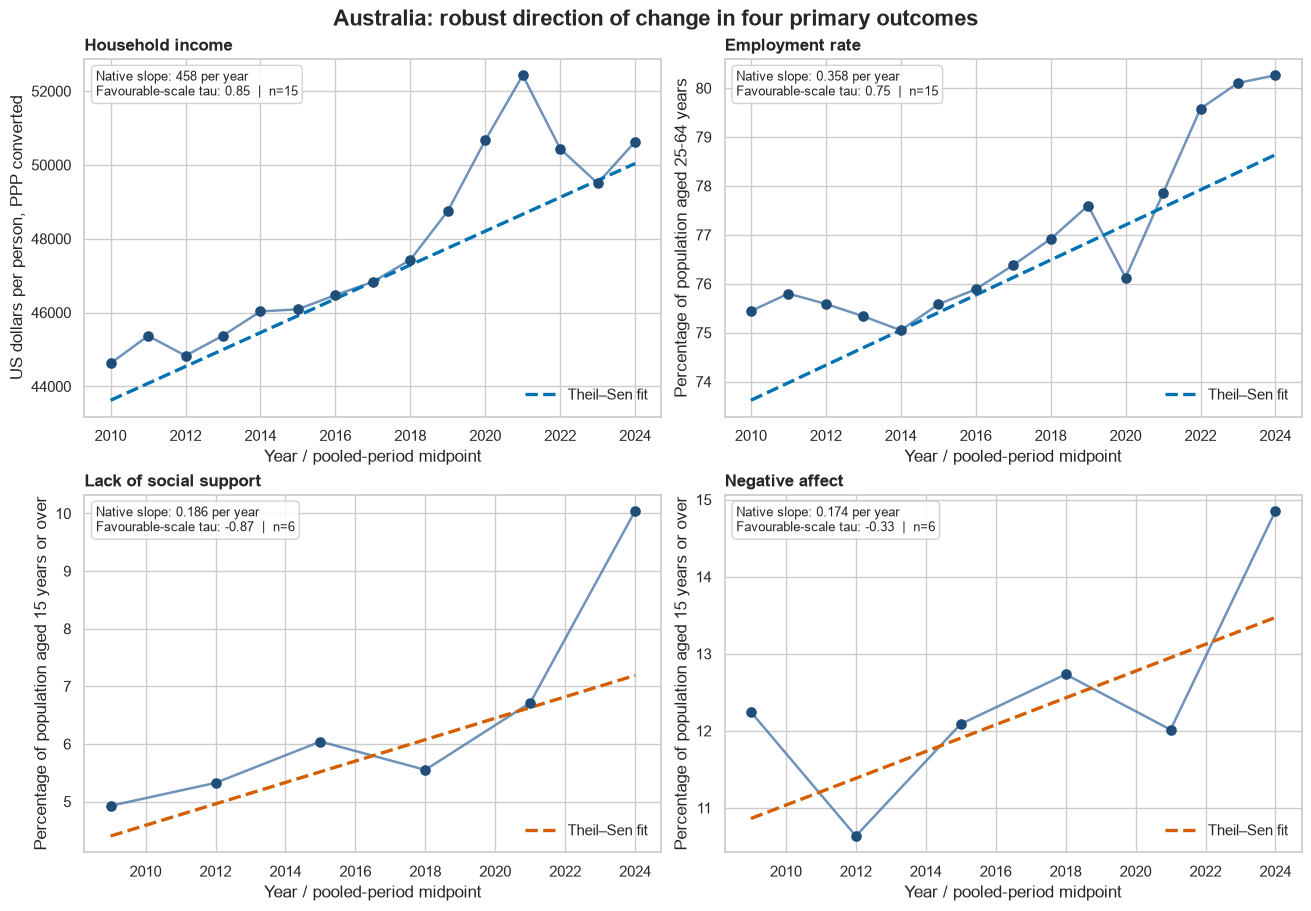

Saved: /Users/y2l/winter-data-challenge/submission/report/figures/method4_australia_theilsen_trends.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
for ax, (code, spec) in zip(axes.flat, INDICATORS.items()):
    g = au_panel[au_panel["indicator_code"].eq(code)].sort_values("time")
    r = aus_results[aus_results["indicator_code"].eq(code)].iloc[0]
    x = g["time"].to_numpy()
    y = g["value"].to_numpy()
    fit = r["theilsen_intercept"] + r["native_slope_per_year"] * x if "theilsen_intercept" in r else None
    # retrieved from the full trend table due to no needs in the CSV summary
    intercept = all_trends.loc[
        all_trends["indicator_code"].eq(code) & all_trends["country_code"].eq("AUS"),
        "theilsen_intercept",
    ].iloc[0]
    fit = intercept + r["native_slope_per_year"] * x
    colour = "#0072B2" if r["favourable_slope_per_year"] > 0 else "#D55E00"

    ax.plot(x, y, color="#4c78a8", linewidth=1.8, alpha=0.8)
    ax.scatter(x, y, color="#1f4e79", s=44, zorder=3)
    ax.plot(x, fit, linestyle="--", color=colour, linewidth=2.4, label="Theil–Sen fit")
    ax.set_title(spec["short_name"], loc="left", fontweight="bold")
    ax.set_xlabel("Year / pooled-period midpoint")
    ax.set_ylabel(g["unit"].iloc[0])
    ax.text(
        0.02, 0.97,
        f"Native slope: {r['native_slope_per_year']:.3g} per year\n"
        f"Favourable-scale tau: {r['kendall_tau_favourable']:.2f}  |  n={int(r['n_independent'])}",
        transform=ax.transAxes, va="top", ha="left", fontsize=9,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "alpha": 0.85, "edgecolor": "#cccccc"},
    )
    ax.legend(frameon=False, loc="lower right")

fig.suptitle("Australia: robust direction of change in four primary outcomes", fontsize=16, fontweight="bold")
figure1 = FIGURE_DIR / "method4_australia_theilsen_trends.png"
fig.savefig(figure1, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {figure1}")

## Figure 2 – Positioning of Australia within the distributions of slope for same-span countries

Each graph is based on favourably oriented slopes such that moving further to the right indicates an increasingly favourable slope trend. The grey points are comparator countries and the orange diamond is Australia. The percentile is calculated against comparators only, matching Method 2.

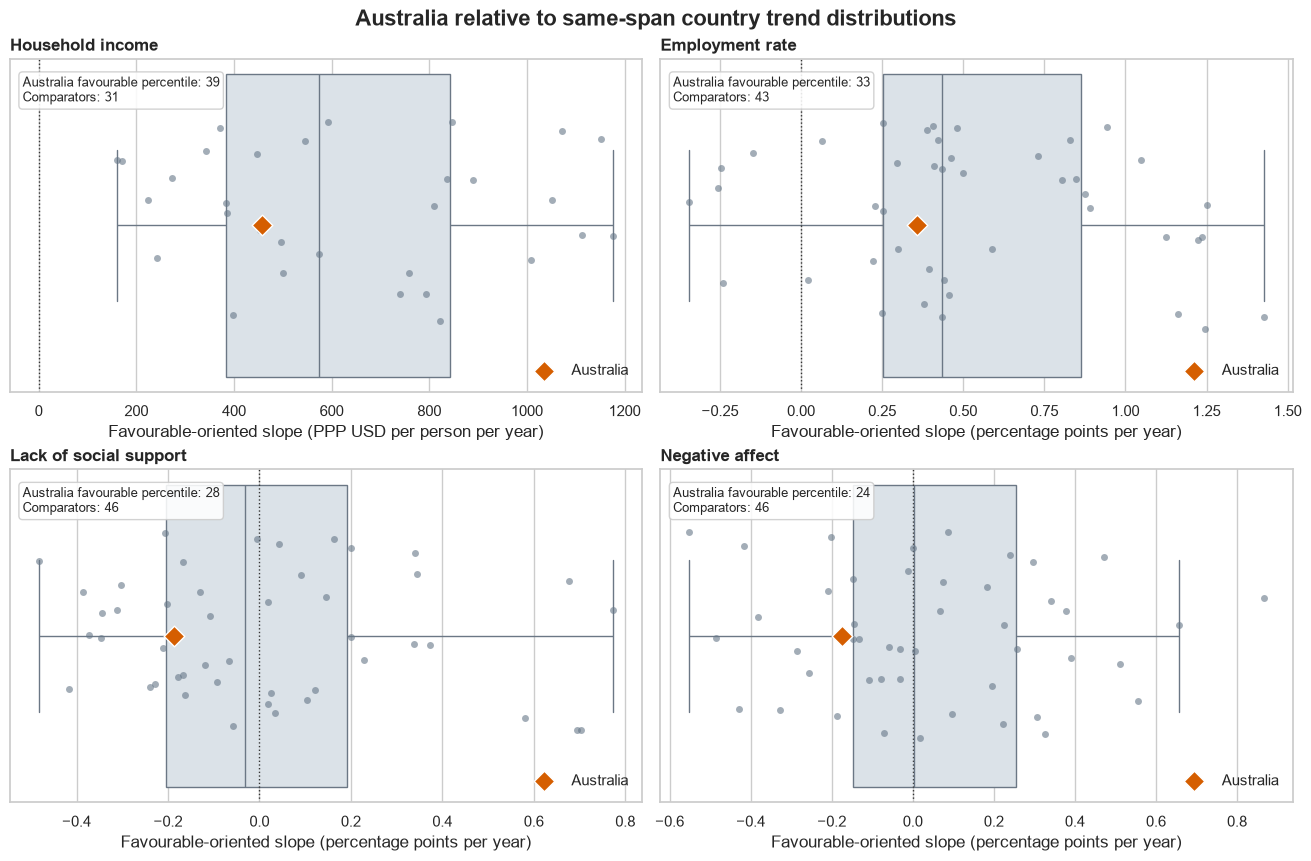

Saved: /Users/y2l/winter-data-challenge/submission/report/figures/method4_country_slope_distributions.png


In [6]:
np.random.seed(20260721)
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), constrained_layout=True)
for ax, (code, spec) in zip(axes.flat, INDICATORS.items()):
    g = eligible[eligible["indicator_code"].eq(code)].copy()
    peers = g[~g["is_australia"]]
    aus = g[g["is_australia"]].iloc[0]
    summary = country_summary[country_summary["indicator_code"].eq(code)].iloc[0]

    sns.boxplot(
        data=peers, x="favourable_slope_per_year", ax=ax, color="#d9e2ea",
        width=0.35, showfliers=False, linecolor="#6b7785"
    )
    sns.stripplot(
        data=peers, x="favourable_slope_per_year", ax=ax,
        color="#667788", alpha=0.6, size=5, jitter=0.12
    )
    ax.scatter(
        aus["favourable_slope_per_year"], 0, marker="D", s=110,
        color="#D55E00", edgecolor="white", linewidth=1, zorder=5, label="Australia"
    )
    ax.axvline(0, color="#333333", linewidth=1, linestyle=":")
    ax.set_title(spec["short_name"], loc="left", fontweight="bold")
    ax.set_xlabel(f"Favourable-oriented slope ({spec['native_unit_per_year']})")
    ax.set_yticks([])
    ax.set_ylabel("")
    ax.text(
        0.02, 0.95,
        f"Australia favourable percentile: {summary['australia_favourable_slope_percentile']:.0f}\n"
        f"Comparators: {int(summary['n_comparator_countries'])}",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.88, "edgecolor": "#cccccc"},
    )
    ax.legend(frameon=False, loc="lower right")

fig.suptitle("Australia relative to same-span country trend distributions", fontsize=16, fontweight="bold")
figure2 = FIGURE_DIR / "method4_country_slope_distributions.png"
fig.savefig(figure2, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {figure2}")

## Plain-language interpretation generated from the estimates

The code below deliberately separates **direction**, **strength of monotonic ordering**, and **statistical uncertainty**. For the two Gallup outcomes, six points can support a statement that methods agree on direction, but they cannot support a strong claim merely because a p-value happens to be small.

In [7]:
def format_p_value(value: float) -> str:
    return "<0.0001" if value < 0.0001 else f"{value:.4f}"


for _, r in aus_results.iterrows():
    direction = r["favourable_direction"]
    relative = (
        "above" if r["favourable_slope_per_year"] > r["comparator_median_favourable_slope"] else "below"
    )
    print(
        f"{r['short_name']}: Australia’s Theil–Sen trend was {direction} "
        f"({r['native_slope_per_year']:.3g} {r['native_unit_per_year']} on the native scale). "
        f"The favourable-scale Kendall tau was {r['kendall_tau_favourable']:.2f} "
        f"(raw p={format_p_value(r['kendall_p_raw'])}, "
        f"Holm p={format_p_value(r['kendall_p_holm'])}, "
        f"n={int(r['n_independent'])}). The slope "
        f"{'agreed' if r['slope_endpoint_agree'] else 'did not agree'} with the "
        f"{r['endpoint_direction']} endpoint direction, and its favourable-oriented slope was {relative} "
        f"the comparator-country median."
    )

print("\nInference caution: standard Kendall p-values and Theil–Sen intervals do not model "
      "temporal dependence. Treat them as exploratory diagnostics, with primary weight on slope "
      "magnitude, direction, coverage and endpoint agreement.")

Household income: Australia’s Theil–Sen trend was favourable (458 PPP USD per person per year on the native scale). The favourable-scale Kendall tau was 0.85 (raw p=<0.0001, Holm p=<0.0001, n=15). The slope agreed with the favourable endpoint direction, and its favourable-oriented slope was below the comparator-country median.
Employment rate: Australia’s Theil–Sen trend was favourable (0.358 percentage points per year on the native scale). The favourable-scale Kendall tau was 0.75 (raw p=<0.0001, Holm p=<0.0001, n=15). The slope agreed with the favourable endpoint direction, and its favourable-oriented slope was below the comparator-country median.
Lack of social support: Australia’s Theil–Sen trend was unfavourable (0.186 percentage points per year on the native scale). The favourable-scale Kendall tau was -0.87 (raw p=0.0167, Holm p=0.0333, n=6). The slope agreed with the unfavourable endpoint direction, and its favourable-oriented slope was below the comparator-country median.
Nega

## TEST: Checks for reproducibility and export files

This verifies the presence of all required statistics, six social outcome data, that all Holm-adjusted p-values are not smaller than original p-values, and that each export is successful.

In [8]:
assert set(aus_results["indicator_code"]) == set(INDICATORS)
assert aus_results["native_slope_per_year"].notna().all()
assert aus_results["slope_endpoint_agree"].notna().all()
assert aus_results["kendall_tau_native"].notna().all()
assert aus_results["kendall_p_raw"].between(0, 1).all()
assert aus_results["kendall_p_holm"].between(0, 1).all()
assert (aus_results["kendall_p_holm"] + 1e-15 >= aus_results["kendall_p_raw"]).all()
assert aus_results.loc[
    aus_results["indicator_code"].isin(["7_1_DEP", "11_2"]), "n_independent"
].eq(6).all()
assert eligible.groupby("indicator_code")["country_code"].apply(lambda s: s.eq("AUS").sum()).eq(1).all()
assert eligible["n_independent"].ge(eligible["required_n_independent"]).all()
assert aus_results["slope_endpoint_agree"].all()
assert aus_results["australia_favourable_slope_percentile"].between(0, 100).all()

exports = [
    TABLE_DIR / "material_social_trend_results.csv",
    TABLE_DIR / "method4_country_slope_distribution.csv",
    TABLE_DIR / "method4_country_slope_summary.csv",
    TABLE_DIR / "method4_independent_social_observations.csv",
    FIGURE_DIR / "method4_australia_theilsen_trends.png",
    FIGURE_DIR / "method4_country_slope_distributions.png",
]
for path in exports:
    assert path.exists() and path.stat().st_size > 0, f"Missing or empty export: {path}"
    print(f"✓ {path.relative_to(PROJECT_ROOT)} ({path.stat().st_size:,} bytes)")

✓ report/tables/material_social_trend_results.csv (2,102 bytes)
✓ report/tables/method4_country_slope_distribution.csv (52,312 bytes)
✓ report/tables/method4_country_slope_summary.csv (531 bytes)
✓ report/tables/method4_independent_social_observations.csv (1,326 bytes)
✓ report/figures/method4_australia_theilsen_trends.png (636,435 bytes)
✓ report/figures/method4_country_slope_distributions.png (346,970 bytes)
